# CE639: AI for Civil Engineering
## Lecture 05: Vector Calculus and Backpropagation
### Scientific Computing Fundamentals

**Instructors:** Dr. Udit Bhatia & Dr. Sushobhan Sen  
**Tutor:** Sarth Dubey  
**Institution:** IIT Gandhinagar

---

### Learning Objectives

By the end of this notebook, you will be able to:
- Evaluate gradients and Jacobians using the chain rule of calculus
- Perform automatic differentiation (autodiff)
- Explain the physical meaning of gradients
- Implement backpropagation

## 🔧 Setup and Installation

In [1]:
# Install dependencies (for Google Colab)
import sys
import subprocess

def install_package(package):
    """Install a package using pip."""
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

# Check if running in Colab
try:
    import google.colab
    IN_COLAB = True
    print("Running in Google Colab ✓")
except:
    IN_COLAB = False
    print("Running locally ✓")

# # Install required packages
# required_packages = ['numpy', 'matplotlib', 'scipy', 'ipywidgets', 'networkx']
# for package in required_packages:
#     try:
#         __import__(package)
#     except ImportError:
#         print(f"Installing {package}...")
#         install_package(package)

print("\n✓ All packages installed successfully!")

Running locally ✓

✓ All packages installed successfully!


In [2]:
# Import standard libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

# Configure matplotlib
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
%matplotlib inline

# Import our custom helper utilities
import sys
sys.path.append('/content')  # For Colab
sys.path.append('..')  # For local

from utils.Lecture_05 import (
    # Calculus
    derivative, partial_derivative, gradient, jacobian, hessian,
    directional_derivative,
    # Computation Graph
    Node, ComputationGraph, forward_pass, backward_pass,
    # Autodiff
    Variable, forward_mode_ad, backward_mode_ad,
    # Neural Network
    Layer, NeuralNetwork, sigmoid, sigmoid_derivative, relu, relu_derivative,
    # Visualizations
    plot_gradient_field, plot_computation_graph, animate_backprop,
    plot_gradient_descent_3d, plot_loss_during_training, plot_jacobian_heatmap,
    # Widgets
    gradient_explorer_widget, chain_rule_widget, backprop_widget,
    neural_network_widget,
    # CE Examples
    structural_stress_gradient, deflection_sensitivity, cost_function_gradient
)

print("✓ All imports successful!")
print("=" * 70)
print("Ready to explore Vector Calculus and Backpropagation!")
print("=" * 70)

✓ All imports successful!
Ready to explore Vector Calculus and Backpropagation!


# 📊 Section 1: Review - Derivatives

## Single Variable Calculus

For a scalar function of one variable $y = f(x)$, we define the **derivative**:

$$\frac{dy}{dx} = \lim_{h \to 0} \frac{f(x+h) - f(x)}{h}$$

**Interpretation:**
- Rate of change of $y$ with respect to $x$
- Slope of the tangent line at point $x$

**Example:** For $f(x) = x^2$, we have $f'(x) = 2x$

Derivative of f(x) = x² at x = 2.0:
  Numerical:  4.000000
  Analytical: 4.000000
  Difference: 2.62e-11


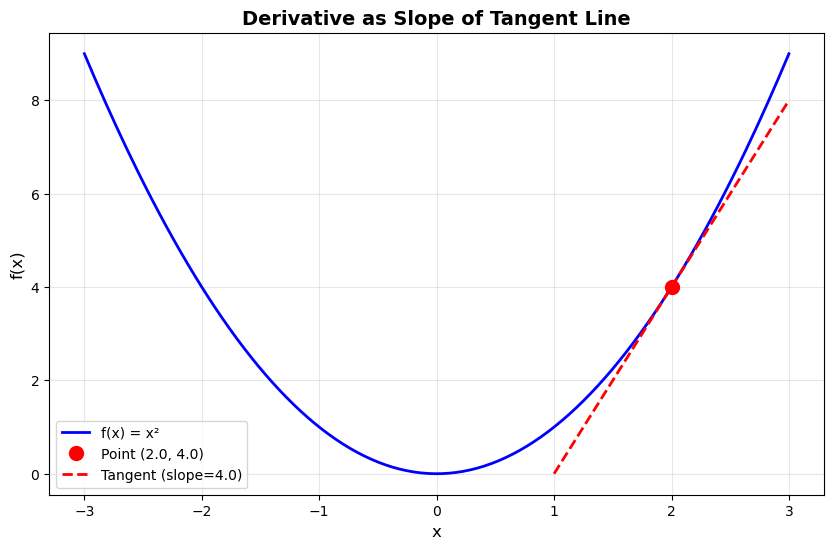

In [3]:
# Demonstrate derivative computation
def f(x):
    """Example function: f(x) = x^2"""
    return x**2

# Analytical derivative
def f_prime(x):
    """Analytical derivative: f'(x) = 2x"""
    return 2*x

# Numerical derivative
x_val = 2.0
numerical_deriv = derivative(f, x_val)
analytical_deriv = f_prime(x_val)

print("Derivative of f(x) = x² at x = 2.0:")
print(f"  Numerical:  {numerical_deriv:.6f}")
print(f"  Analytical: {analytical_deriv:.6f}")
print(f"  Difference: {abs(numerical_deriv - analytical_deriv):.2e}")

# Visualize
x = np.linspace(-3, 3, 200)
y = f(x)

plt.figure(figsize=(10, 6))
plt.plot(x, y, 'b-', linewidth=2, label='f(x) = x²')
plt.plot(x_val, f(x_val), 'ro', markersize=10, label=f'Point ({x_val}, {f(x_val)})')

# Tangent line
tangent_x = np.array([x_val - 1, x_val + 1])
tangent_y = f(x_val) + f_prime(x_val) * (tangent_x - x_val)
plt.plot(tangent_x, tangent_y, 'r--', linewidth=2, label=f"Tangent (slope={f_prime(x_val)})")

plt.xlabel('x', fontsize=12)
plt.ylabel('f(x)', fontsize=12)
plt.title('Derivative as Slope of Tangent Line', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Partial Derivatives

For a multivariable function $f(\mathbf{x})$ where $\mathbf{x} = [x_1, x_2, \ldots, x_n]$, we define **partial derivatives**:

$$\frac{\partial f}{\partial x_i} = \lim_{h \to 0} \frac{f(x_1, \ldots, x_i + h, \ldots, x_n) - f(x_1, \ldots, x_i, \ldots, x_n)}{h}$$

**Interpretation:**
- Rate of change of $f$ with respect to $x_i$, holding all other variables constant

**Example:** For $f(x, y) = x^2 + 3y$:
- $\frac{\partial f}{\partial x} = 2x$
- $\frac{\partial f}{\partial y} = 3$

In [4]:
# Demonstrate partial derivatives
def f_2d(x):
    """f(x, y) = x² + 3y"""
    return x[0]**2 + 3*x[1]

point = np.array([2.0, 3.0])

# Compute partial derivatives
df_dx = partial_derivative(f_2d, point, i=0)
df_dy = partial_derivative(f_2d, point, i=1)

print("Partial derivatives of f(x, y) = x² + 3y at (2, 3):")
print(f"  ∂f/∂x = {df_dx:.6f}  (analytical: 2x = {2*point[0]:.6f})")
print(f"  ∂f/∂y = {df_dy:.6f}  (analytical: 3)")

Partial derivatives of f(x, y) = x² + 3y at (2, 3):
  ∂f/∂x = 4.000000  (analytical: 2x = 4.000000)
  ∂f/∂y = 3.000000  (analytical: 3)


# 🎯 Section 2: Gradients

## The Gradient Vector

The **gradient** of a scalar function $f: \mathbb{R}^n \to \mathbb{R}$ is:

$$\nabla f(\mathbf{x}) = \begin{bmatrix} \frac{\partial f}{\partial x_1} \\ \frac{\partial f}{\partial x_2} \\ \vdots \\ \frac{\partial f}{\partial x_n} \end{bmatrix}$$

**Properties:**
- The gradient is a **vector** in $\mathbb{R}^n$
- Points in the direction of **steepest increase**
- Magnitude indicates the rate of increase

**Key Insight:** To minimize $f$, move in the direction $-\nabla f$ (gradient descent!)

In [5]:
# Compute gradient
grad = gradient(f_2d, point)

print("Gradient of f(x, y) = x² + 3y at (2, 3):")
print(f"  ∇f = [{grad[0]:.6f}, {grad[1]:.6f}]")
print(f"  Magnitude: ||∇f|| = {np.linalg.norm(grad):.6f}")
print(f"  Direction: {grad / np.linalg.norm(grad)}")

Gradient of f(x, y) = x² + 3y at (2, 3):
  ∇f = [4.000000, 3.000000]
  Magnitude: ||∇f|| = 5.000000
  Direction: [0.8 0.6]


## Visualizing Gradients

Let's visualize the gradient field for different functions.

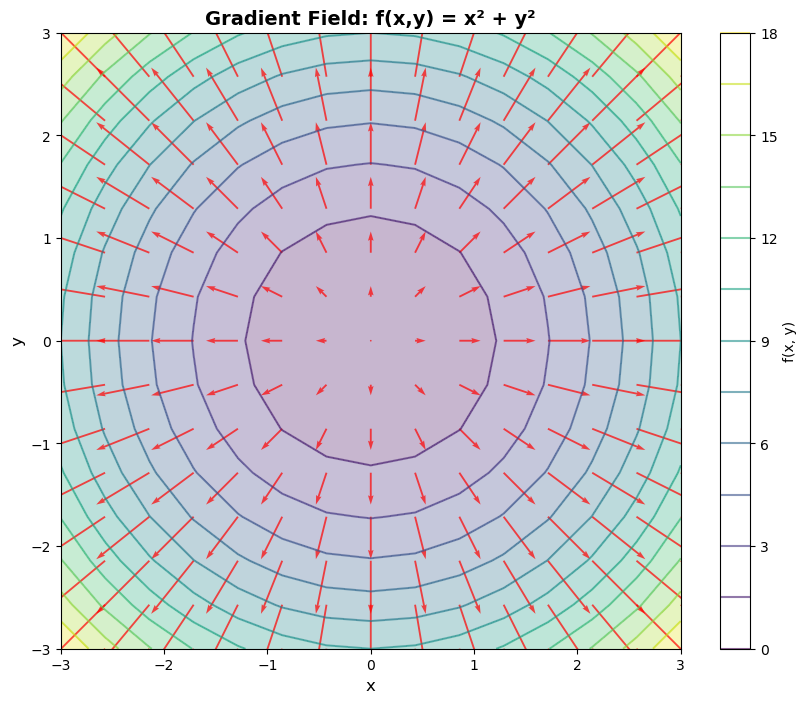

In [6]:
# Quadratic bowl
def quadratic_bowl(x):
    """f(x, y) = x² + y²"""
    return x[0]**2 + x[1]**2

fig, ax = plot_gradient_field(quadratic_bowl, (-3, 3), (-3, 3), 
                               resolution=15, title="Gradient Field: f(x,y) = x² + y²")
plt.show()

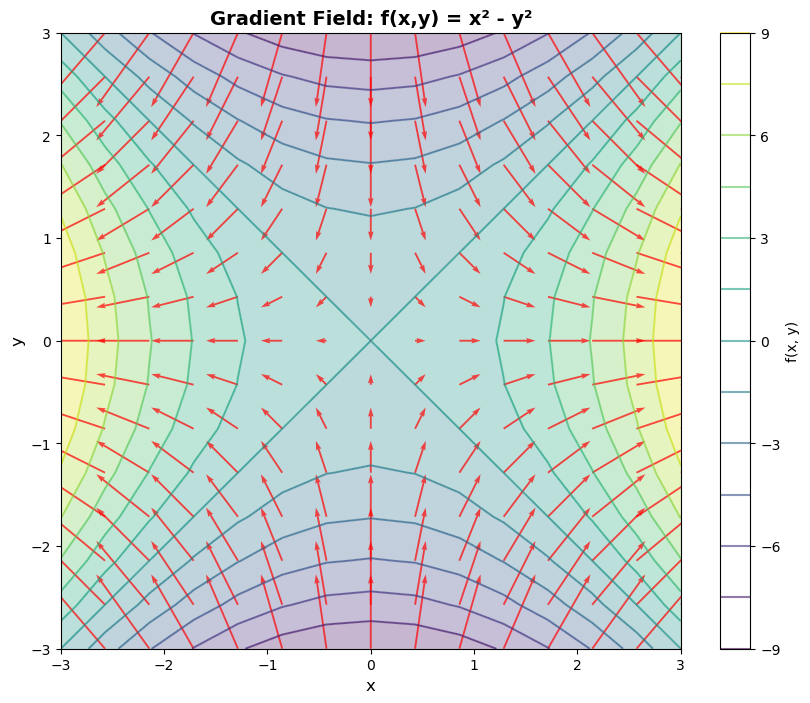

In [7]:
# Saddle function
def saddle(x):
    """f(x, y) = x² - y²"""
    return x[0]**2 - x[1]**2

fig, ax = plot_gradient_field(saddle, (-3, 3), (-3, 3),
                               resolution=15, title="Gradient Field: f(x,y) = x² - y²")
plt.show()

### 🎮 Interactive Widget: Gradient Explorer

In [8]:
gradient_explorer_widget()

interactive(children=(FloatSlider(value=1.0, description='x:', max=2.0, min=-2.0, step=0.2, style=SliderStyle(…

# 📐 Section 3: Jacobians

## Vector-Valued Functions

For a vector function $\mathbf{f}: \mathbb{R}^n \to \mathbb{R}^m$ where:

$$\mathbf{f}(\mathbf{x}) = \begin{bmatrix} f_1(\mathbf{x}) \\ f_2(\mathbf{x}) \\ \vdots \\ f_m(\mathbf{x}) \end{bmatrix}$$

The **Jacobian matrix** is:

$$\mathbf{J}_{\mathbf{f}}(\mathbf{x}) = \begin{bmatrix}
\frac{\partial f_1}{\partial x_1} & \frac{\partial f_1}{\partial x_2} & \cdots & \frac{\partial f_1}{\partial x_n} \\
\frac{\partial f_2}{\partial x_1} & \frac{\partial f_2}{\partial x_2} & \cdots & \frac{\partial f_2}{\partial x_n} \\
\vdots & \vdots & \ddots & \vdots \\
\frac{\partial f_m}{\partial x_1} & \frac{\partial f_m}{\partial x_2} & \cdots & \frac{\partial f_m}{\partial x_n}
\end{bmatrix}$$

**Size:** $m \times n$ matrix

**Interpretation:** $J_{ij} = \frac{\partial f_i}{\partial x_j}$ tells us how output $i$ changes with input $j$

Jacobian of polar to Cartesian transformation at (r=2, θ=π/4):
J = 
[[ 0.70710678 -1.41421356]
 [ 0.70710678  1.41421356]]

Analytical Jacobian:
[[ 0.70710678 -1.41421356]
 [ 0.70710678  1.41421356]]


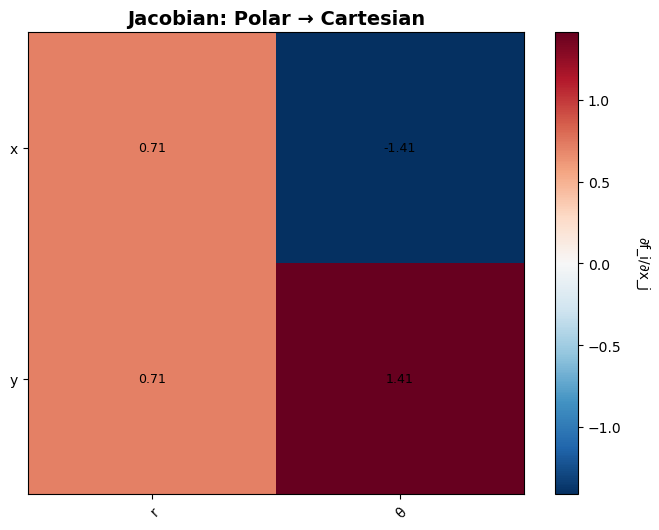

In [9]:
# Example: Polar to Cartesian transformation
def polar_to_cartesian(x):
    """
    Convert polar (r, θ) to Cartesian (x, y).
    
    f₁(r, θ) = r cos(θ)
    f₂(r, θ) = r sin(θ)
    """
    r, theta = x[0], x[1]
    return np.array([r * np.cos(theta), r * np.sin(theta)])

# Compute Jacobian
point_polar = np.array([2.0, np.pi/4])
J = jacobian(polar_to_cartesian, point_polar)

print("Jacobian of polar to Cartesian transformation at (r=2, θ=π/4):")
print(f"J = \n{J}")
print(f"\nAnalytical Jacobian:")
r, theta = point_polar
J_analytical = np.array([
    [np.cos(theta), -r*np.sin(theta)],
    [np.sin(theta),  r*np.cos(theta)]
])
print(J_analytical)

# Visualize as heatmap
fig, ax = plot_jacobian_heatmap(J, x_labels=['r', 'θ'], y_labels=['x', 'y'],
                                title='Jacobian: Polar → Cartesian')
plt.show()

# 🔗 Section 4: Chain Rule

## Chain Rule for Scalar Functions

For composed functions $y = f(g(x))$:

$$\frac{dy}{dx} = \frac{df}{dg} \cdot \frac{dg}{dx}$$

**Vector version:** For $\mathbf{z} = g(\mathbf{x})$ and $y = f(\mathbf{z})$:

$$\nabla_{\mathbf{x}} y = (\mathbf{J}_{\mathbf{g}}(\mathbf{x}))^T \nabla_{\mathbf{z}} y$$

**This is the foundation of backpropagation!**

In [10]:
# Example: y = (x² + 1)³
# Let u = x² + 1, then y = u³
# dy/dx = dy/du * du/dx = 3u² * 2x = 6x(x² + 1)²

x_val = 2.0

# Inner function
u = x_val**2 + 1
du_dx = 2 * x_val

# Outer function
y = u**3
dy_du = 3 * u**2

# Chain rule
dy_dx_chain = dy_du * du_dx

# Analytical
dy_dx_analytical = 6 * x_val * (x_val**2 + 1)**2

print("Chain Rule Example: y = (x² + 1)³ at x = 2")
print(f"  Inner: u = x² + 1 = {u}")
print(f"  du/dx = 2x = {du_dx}")
print(f"  Outer: y = u³ = {y}")
print(f"  dy/du = 3u² = {dy_du}")
print(f"  Chain rule: dy/dx = dy/du × du/dx = {dy_dx_chain}")
print(f"  Analytical: dy/dx = {dy_dx_analytical}")
print(f"  Match: {np.isclose(dy_dx_chain, dy_dx_analytical)}")

Chain Rule Example: y = (x² + 1)³ at x = 2
  Inner: u = x² + 1 = 5.0
  du/dx = 2x = 4.0
  Outer: y = u³ = 125.0
  dy/du = 3u² = 75.0
  Chain rule: dy/dx = dy/du × du/dx = 300.0
  Analytical: dy/dx = 300.0
  Match: True


### 🎮 Interactive Widget: Chain Rule Visualization

In [11]:
chain_rule_widget()

interactive(children=(FloatSlider(value=1.0, description='x value:', max=2.0, min=-2.0, style=SliderStyle(desc…

## Chain Rule for Jacobians

For composed vector functions $\mathbf{y} = \mathbf{f}(\mathbf{g}(\mathbf{x}))$:

$$\mathbf{J}_{\mathbf{y}}(\mathbf{x}) = \mathbf{J}_{\mathbf{f}}(\mathbf{g}(\mathbf{x})) \cdot \mathbf{J}_{\mathbf{g}}(\mathbf{x})$$

**Key Insight:** Jacobians multiply in the same order as function composition!

In [12]:
# Example: Compose two transformations
def g(x):
    """First transformation: (x, y) → (x+y, x-y)"""
    return np.array([x[0] + x[1], x[0] - x[1]])

def f(z):
    """Second transformation: (u, v) → (u², v²)"""
    return np.array([z[0]**2, z[1]**2])

def composed(x):
    """Composition: f(g(x))"""
    return f(g(x))

# Compute Jacobians
x_point = np.array([2.0, 1.0])
z_point = g(x_point)

J_g = jacobian(g, x_point)
J_f = jacobian(f, z_point)
J_composed_direct = jacobian(composed, x_point)
J_composed_chain = J_f @ J_g

print("Chain Rule for Jacobians:")
print(f"Point: x = {x_point}")
print(f"Intermediate: z = g(x) = {z_point}")
print(f"\nJ_g (at x):\n{J_g}")
print(f"\nJ_f (at z):\n{J_f}")
print(f"\nJ_composed (direct):\n{J_composed_direct}")
print(f"\nJ_composed (chain rule: J_f @ J_g):\n{J_composed_chain}")
print(f"\nMatch: {np.allclose(J_composed_direct, J_composed_chain)}")

Chain Rule for Jacobians:
Point: x = [2. 1.]
Intermediate: z = g(x) = [3. 1.]

J_g (at x):
[[ 1.  1.]
 [ 1. -1.]]

J_f (at z):
[[6. 0.]
 [0. 2.]]

J_composed (direct):
[[ 6.  6.]
 [ 2. -2.]]

J_composed (chain rule: J_f @ J_g):
[[ 6.  6.]
 [ 2. -2.]]

Match: True


# 🌍 Section 5: Physical Meaning of Gradients

## Gradient as Direction

**Topographic Interpretation:**
- Consider a surface $z = f(x, y)$ representing elevation
- If you're standing at a point, which direction should you step to climb uphill fastest?
- **Answer:** The gradient $\nabla f$ points in that direction!

**Magnitude:**
- $||\nabla f||$ tells you how steep the climb is

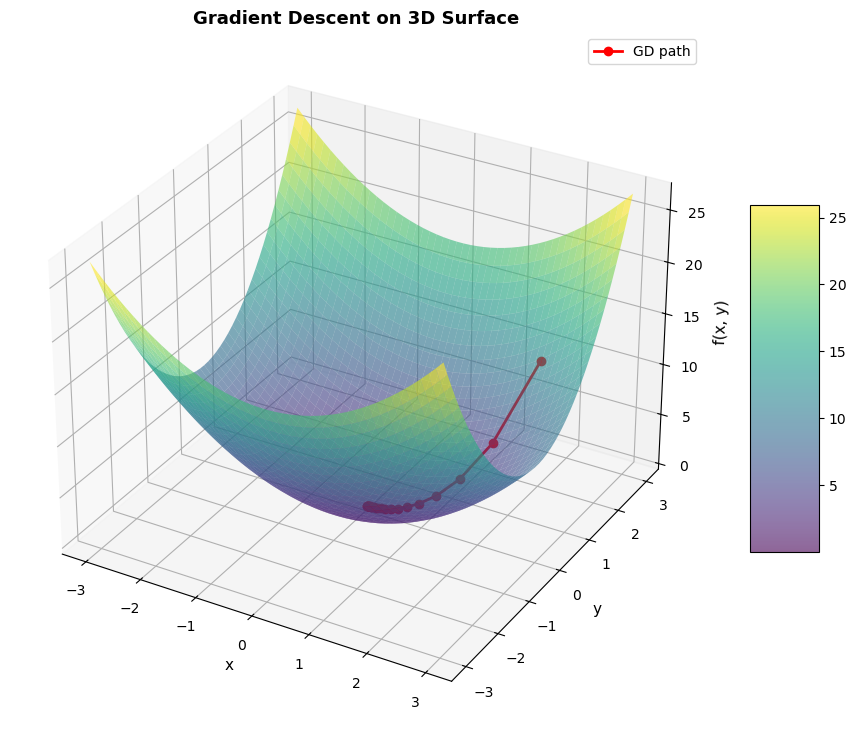

In [13]:
# Visualize gradient as direction on 3D surface
def paraboloid(x):
    """f(x, y) = x² + 2y²"""
    return x[0]**2 + 2*x[1]**2

# Create gradient descent path
x_history = [np.array([2.0, 2.0])]
learning_rate = 0.1

for _ in range(20):
    x_current = x_history[-1]
    grad = gradient(paraboloid, x_current)
    x_next = x_current - learning_rate * grad
    x_history.append(x_next)

x_history = np.array(x_history)

# Plot 3D surface with path
fig, ax = plot_gradient_descent_3d(paraboloid, x_history, (-3, 3), (-3, 3))
plt.show()

## Taylor Series Interpretation

The gradient provides the **best local linear approximation**:

$$f(\mathbf{x} + \Delta\mathbf{x}) \approx f(\mathbf{x}) + \nabla f(\mathbf{x})^T \Delta\mathbf{x}$$

**Interpretation:**
- The gradient tells us how the function changes for small steps
- This is why gradient descent works: we use the gradient to predict which direction decreases the function

In [14]:
# Demonstrate Taylor approximation
def f_taylor(x):
    """f(x, y) = x² + y²"""
    return x[0]**2 + x[1]**2

x0 = np.array([1.0, 1.0])
f_x0 = f_taylor(x0)
grad_x0 = gradient(f_taylor, x0)

# Test approximation at nearby points
deltas = [np.array([0.1, 0.0]), np.array([0.0, 0.1]), np.array([0.1, 0.1])]

print("Taylor Series Approximation:")
print(f"Base point: x₀ = {x0}, f(x₀) = {f_x0:.4f}")
print(f"Gradient: ∇f(x₀) = {grad_x0}")
print("\nApproximation quality:")

for delta in deltas:
    x_new = x0 + delta
    f_true = f_taylor(x_new)
    f_approx = f_x0 + np.dot(grad_x0, delta)
    error = abs(f_true - f_approx)
    
    print(f"  Δx = {delta}: f_true = {f_true:.6f}, f_approx = {f_approx:.6f}, error = {error:.6f}")

Taylor Series Approximation:
Base point: x₀ = [1. 1.], f(x₀) = 2.0000
Gradient: ∇f(x₀) = [2. 2.]

Approximation quality:
  Δx = [0.1 0. ]: f_true = 2.210000, f_approx = 2.200000, error = 0.010000
  Δx = [0.  0.1]: f_true = 2.210000, f_approx = 2.200000, error = 0.010000
  Δx = [0.1 0.1]: f_true = 2.420000, f_approx = 2.400000, error = 0.020000


# 🤖 Section 6: Automatic Differentiation

%% [markdown]
## Why Autodiff?

**Three approaches to computing derivatives:**

1. **Manual (Symbolic) Differentiation**
   - Derive formulas by hand
   - ❌ Not feasible for complex models
   - ❌ Error-prone

2. **Numerical Differentiation**
   - Finite differences: $f'(x) \approx \frac{f(x+h) - f(x-h)}{2h}$
   - ❌ Slow (requires multiple function evaluations)
   - ❌ Numerical errors accumulate

3. **Automatic Differentiation (Autodiff)**
   - Systematically applies chain rule
   - ✓ Exact derivatives (machine precision)
   - ✓ Efficient
   - ✓ Used in all modern AI frameworks (PyTorch, TensorFlow)

## Forward-Mode Autodiff

**Idea:** Use **dual numbers** to carry derivatives along with values.

A dual number: $a + b\varepsilon$ where $\varepsilon^2 = 0$

**Arithmetic rules:**
- $(a + b\varepsilon) + (c + d\varepsilon) = (a+c) + (b+d)\varepsilon$
- $(a + b\varepsilon) \times (c + d\varepsilon) = ac + (ad + bc)\varepsilon$

**Each operation carries (value, derivative) pairs forward**

In [15]:
# Demonstrate forward-mode AD
def f_dual(vars):
    """f(x, y) = x² + 3y"""
    x, y = vars[0], vars[1]
    return x**2 + 3*y

point = [2.0, 3.0]

# Compute ∂f/∂x using forward-mode AD
value, deriv_x = forward_mode_ad(f_dual, point, i=0)
print("Forward-Mode AD: f(x, y) = x² + 3y at (2, 3)")
print(f"  f(2, 3) = {value}")
print(f"  ∂f/∂x = {deriv_x} (analytical: 2x = {2*point[0]})")

# Compute ∂f/∂y
value, deriv_y = forward_mode_ad(f_dual, point, i=1)
print(f"  ∂f/∂y = {deriv_y} (analytical: 3)")

Forward-Mode AD: f(x, y) = x² + 3y at (2, 3)
  f(2, 3) = 13.0
  ∂f/∂x = 4.0 (analytical: 2x = 4.0)
  ∂f/∂y = 3.0 (analytical: 3)


## Backward-Mode Autodiff

**Idea:** Build a computation graph, then traverse it **backward** to compute gradients.

**Key concept:** For each variable $v$, define the **adjoint** (upstream gradient):

$$\bar{v} = \frac{\partial L}{\partial v}$$

where $L$ is the final output (loss).

**This is backpropagation!**

# 📊 Section 7: Computation Graphs

## What is a Computation Graph?

A **Directed Acyclic Graph (DAG)** where:
- **Nodes** represent variables or operations
- **Edges** represent data flow

**Example:** For $y = (x_1 + x_2)^2$:
- Inputs: $x_1$, $x_2$
- Intermediate: $z = x_1 + x_2$
- Output: $y = z^2$

Forward pass: y = (x₁ + x₂)² = (2.0 + 3.0)² = 25.0

Backward pass (gradients):
  ∂y/∂x1 = 10.0
  ∂y/∂x2 = 10.0


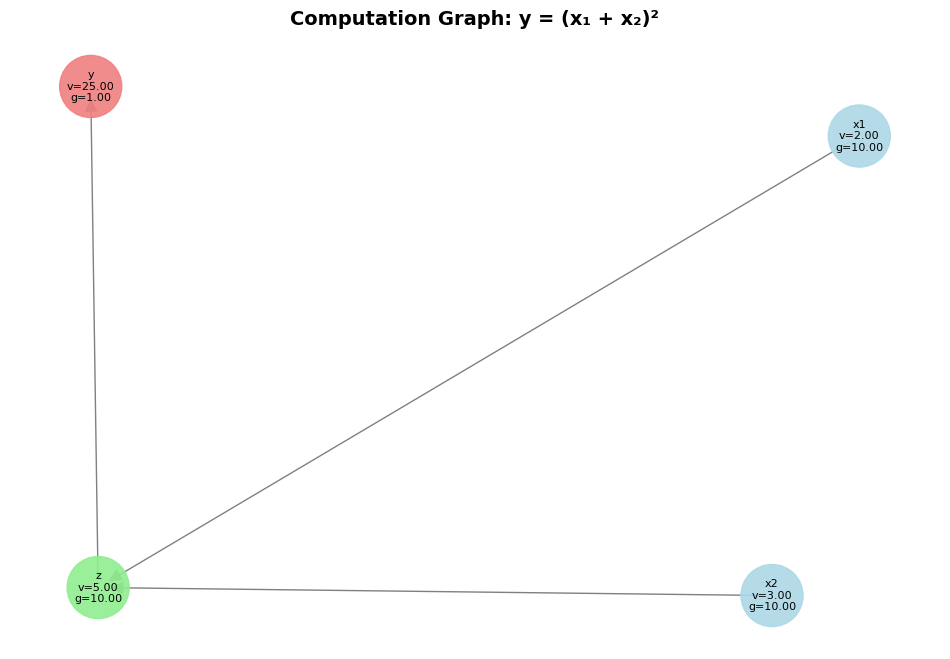

In [16]:
# Create simple computation graph
from utils.Lecture_05.computation_graph import create_simple_graph

graph = create_simple_graph(x1_val=2.0, x2_val=3.0)

# Forward pass
y_val = graph.forward()
print(f"Forward pass: y = (x₁ + x₂)² = ({2.0} + {3.0})² = {y_val}")

# Backward pass
gradients = graph.backward()
print(f"\nBackward pass (gradients):")
for name, grad in gradients.items():
    print(f"  ∂y/∂{name} = {grad}")

# Visualize graph
fig, ax = plot_computation_graph(graph, title="Computation Graph: y = (x₁ + x₂)²")
plt.show()

### 🎮 Interactive Widget: Backpropagation Step-Through

In [ ]:
backprop_widget()

interactive(children=(FloatSlider(value=2.0, description='x₁:', max=3.0, min=-3.0, step=0.5, style=SliderStyle…

# 🔄 Section 8: Backpropagation Algorithm

## Backpropagation = Reverse-Mode AD on Computation Graphs

**Algorithm:**
1. **Forward Pass:** Compute all values from inputs to output
2. **Backward Pass:** Compute gradients from output to inputs

**For each node $v$ with children $c_1, c_2, \ldots$:**

$$\bar{v} = \sum_i \bar{c_i} \cdot \frac{\partial c_i}{\partial v}$$

**Key Features:**
- Gradients flow backward through the graph
- Each node applies only its **local derivative**
- One backward pass gives gradients w.r.t. **all inputs**
- Cost ≈ 2× forward pass

In [18]:
# Detailed backpropagation example
print("Backpropagation Example: y = (x₁ + x₂)²")
print("=" * 50)

# Forward pass
x1, x2 = 2.0, 3.0
z = x1 + x2
y = z**2

print("Forward Pass:")
print(f"  x₁ = {x1}")
print(f"  x₂ = {x2}")
print(f"  z = x₁ + x₂ = {z}")
print(f"  y = z² = {y}")

# Backward pass
print("\nBackward Pass:")

# Output gradient (by definition)
dy_dy = 1.0
print(f"  ∂y/∂y = {dy_dy}")

# Gradient at z
dy_dz = dy_dy * 2*z  # Local derivative: ∂(z²)/∂z = 2z
print(f"  ∂y/∂z = ∂y/∂y × ∂y/∂z = {dy_dy} × {2*z} = {dy_dz}")

# Gradients at inputs
dy_dx1 = dy_dz * 1.0  # Local derivative: ∂(x₁+x₂)/∂x₁ = 1
dy_dx2 = dy_dz * 1.0  # Local derivative: ∂(x₁+x₂)/∂x₂ = 1

print(f"  ∂y/∂x₁ = ∂y/∂z × ∂z/∂x₁ = {dy_dz} × 1 = {dy_dx1}")
print(f"  ∂y/∂x₂ = ∂y/∂z × ∂z/∂x₂ = {dy_dz} × 1 = {dy_dx2}")

Backpropagation Example: y = (x₁ + x₂)²
Forward Pass:
  x₁ = 2.0
  x₂ = 3.0
  z = x₁ + x₂ = 5.0
  y = z² = 25.0

Backward Pass:
  ∂y/∂y = 1.0
  ∂y/∂z = ∂y/∂y × ∂y/∂z = 1.0 × 10.0 = 10.0
  ∂y/∂x₁ = ∂y/∂z × ∂z/∂x₁ = 10.0 × 1 = 10.0
  ∂y/∂x₂ = ∂y/∂z × ∂z/∂x₂ = 10.0 × 1 = 10.0


# 🧠 Section 9: Neural Network Backpropagation

## Single-Layer Neural Network

**Architecture:**
- Input: $\mathbf{x} \in \mathbb{R}^{n_{in}}$
- Weights: $W \in \mathbb{R}^{n_{out} \times n_{in}}$, $\mathbf{b} \in \mathbb{R}^{n_{out}}$
- Pre-activation: $\mathbf{z} = W\mathbf{x} + \mathbf{b}$
- Activation: $\mathbf{a} = \sigma(\mathbf{z})$
- Loss: $L = \ell(\mathbf{a}, \mathbf{y}_{true})$

**Backpropagation:**
1. $\frac{\partial L}{\partial \mathbf{a}} = \ell'(\mathbf{a})$
2. $\frac{\partial L}{\partial \mathbf{z}} = \frac{\partial L}{\partial \mathbf{a}} \odot \sigma'(\mathbf{z})$
3. $\frac{\partial L}{\partial W} = \frac{\partial L}{\partial \mathbf{z}} \mathbf{x}^T$
4. $\frac{\partial L}{\partial \mathbf{b}} = \frac{\partial L}{\partial \mathbf{z}}$

In [19]:
# Create simple neural network
from utils.Lecture_05.neural_network import demonstrate_backprop_step_by_step

# Create network
network = NeuralNetwork([2, 3, 1], activations=['sigmoid', 'linear'])

# Sample input and target
X = np.array([[0.5], [0.8]])
Y = np.array([[1.0]])

# Demonstrate backprop step by step
result = demonstrate_backprop_step_by_step(X, Y, network)

print("Neural Network Backpropagation:")
print("=" * 50)
print("\nForward Pass:")
print(f"  Input: {X.flatten()}")
print(f"  Prediction: {result['forward']['prediction'].flatten()}")
print(f"  Target: {Y.flatten()}")
print(f"  Loss: {result['forward']['loss']:.6f}")

print("\nBackward Pass (Gradients):")
for i, grad_info in enumerate(result['backward']['gradients']):
    print(f"\n  Layer {grad_info['layer']}:")
    print(f"    dW shape: {grad_info['dW'].shape}")
    print(f"    db shape: {grad_info['db'].shape}")

Neural Network Backpropagation:

Forward Pass:
  Input: [0.5 0.8]
  Prediction: [-0.11779381]
  Target: [1.]
  Loss: 1.249463

Backward Pass (Gradients):

  Layer 0:
    dW shape: (3, 2)
    db shape: (3, 1)

  Layer 1:
    dW shape: (1, 3)
    db shape: (1, 1)


## Training a Neural Network

**Training Loop:**
```python
for epoch in range(n_epochs):
    # Forward pass
    y_pred = network.forward(X)
    loss = compute_loss(y_pred, Y)
    
    # Backward pass
    network.backward(Y, y_pred)
    
    # Update weights
    network.update(learning_rate)
```

Training Neural Network on XOR Problem


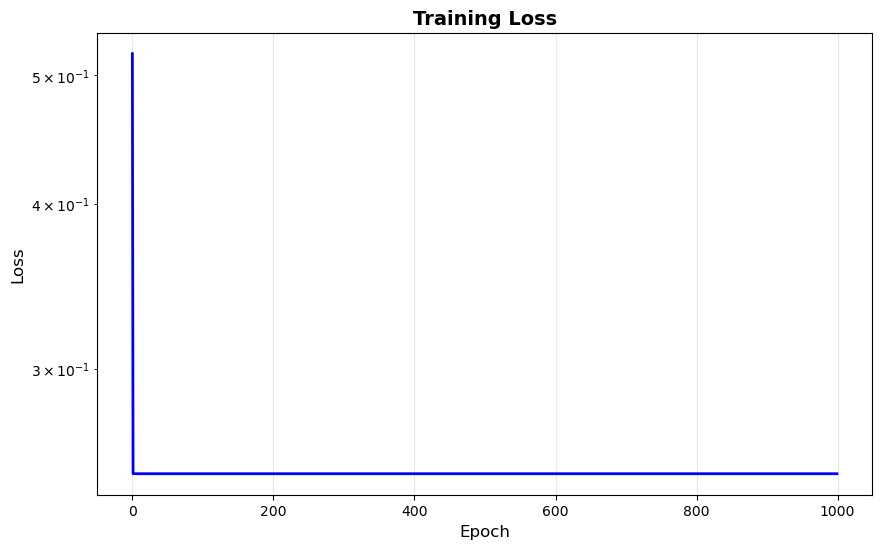


Results:
Input  →  Target  Prediction
[0 0]  →    0      0.5003
[0 1]  →    1      0.5009
[1 0]  →    1      0.4991
[1 1]  →    0      0.4997


In [20]:
# Train on XOR problem
print("Training Neural Network on XOR Problem")
print("=" * 50)

# XOR dataset
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]]).T
Y_xor = np.array([[0, 1, 1, 0]])

# Create and train network
network_xor = NeuralNetwork([2, 4, 1], activations=['sigmoid', 'linear'])
loss_history = network_xor.train(X_xor, Y_xor, epochs=1000, learning_rate=0.5, verbose=False)

# Plot training curve
fig, ax = plot_loss_during_training(loss_history)
plt.show()

# Test predictions
predictions = network_xor.predict(X_xor)
print("\nResults:")
print("Input  →  Target  Prediction")
for i in range(4):
    print(f"{X_xor[:, i]}  →    {Y_xor[0, i]}      {predictions[0, i]:.4f}")

### 🎮 Interactive Widget: Neural Network Training

In [ ]:
neural_network_widget()

interactive(children=(FloatSlider(value=0.5, description='Learning Rate:', max=1.0, min=0.01, step=0.05, style…

# 🏗️ Section 10: CE Applications

## Sensitivity Analysis in Structural Engineering

**Problem:** How sensitive is beam stress to design parameters?

**Stress formula:**
$$\sigma = \frac{M \cdot c}{I} = \frac{M \cdot (h/2)}{bh^3/12} = \frac{6M}{bh^2}$$

**Gradients:**
- $\frac{\partial \sigma}{\partial b} = -\frac{6M}{b^2h^2}$ (stress decreases as width increases)
- $\frac{\partial \sigma}{\partial h} = -\frac{12M}{bh^3}$ (stress decreases as height increases)

In [22]:
# Structural stress gradient
stress_result = structural_stress_gradient()

print("Structural Stress Sensitivity Analysis")
print("=" * 50)
print(f"\nBeam parameters: b = {stress_result['example']['params'][0]:.2f} m, h = {stress_result['example']['params'][1]:.2f} m")
print(f"Stress: σ = {stress_result['example']['stress']:.2f} MPa")
print(f"\nGradient: ∇σ = {stress_result['example']['gradient']}")
print(f"\nInterpretation:")
for key, val in stress_result['example']['interpretation'].items():
    print(f"  {key}: {val}")

Structural Stress Sensitivity Analysis

Beam parameters: b = 0.30 m, h = 0.50 m
Stress: σ = 8000.00 MPa

Gradient: ∇σ = [-26666.66666667  -1333.33333333]

Interpretation:
  dsigma_db: -26666.67 MPa/m (stress decreases as width increases)
  dsigma_dh: -1333.33 MPa/m (stress decreases as height increases)


## Deflection Sensitivity

**Deflection formula:**
$$\delta = \frac{5wL^4}{384EI}$$

where $I = \frac{bh^3}{12}$

In [23]:
# Deflection sensitivity
deflection_result = deflection_sensitivity()

print("Beam Deflection Sensitivity Analysis")
print("=" * 50)
print(f"\nParameters: b = {deflection_result['example']['params'][0]:.2f} m, h = {deflection_result['example']['params'][1]:.2f} m, L = {deflection_result['example']['params'][2]:.2f} m")
print(f"Deflection: δ = {deflection_result['example']['deflection']:.2f} mm")
print(f"\nJacobian: {deflection_result['example']['jacobian']}")
print(f"\nSensitivity:")
for key, val in deflection_result['example']['sensitivity'].items():
    print(f"  {key}: {val}")

Beam Deflection Sensitivity Analysis

Parameters: b = 0.30 m, h = 0.50 m, L = 10.00 m
Deflection: δ = 2083.33 mm

Jacobian: [ -6944.44445217 -12500.00001664    833.3333333 ]

Sensitivity:
  width: -6944.44 mm/m
  height: -12500.00 mm/m
  span: 833.33 mm/m


## Cost Optimization

**Problem:** Minimize project cost by optimizing material grades.

Cost Function Optimization

Initial parameters: fc = 30.00 MPa, fy = 350.00 MPa
Initial cost: $3988.10

Optimal parameters: fc = 158.03 MPa, fy = 355.03 MPa
Optimal cost: $2636.82

Savings: $1351.27


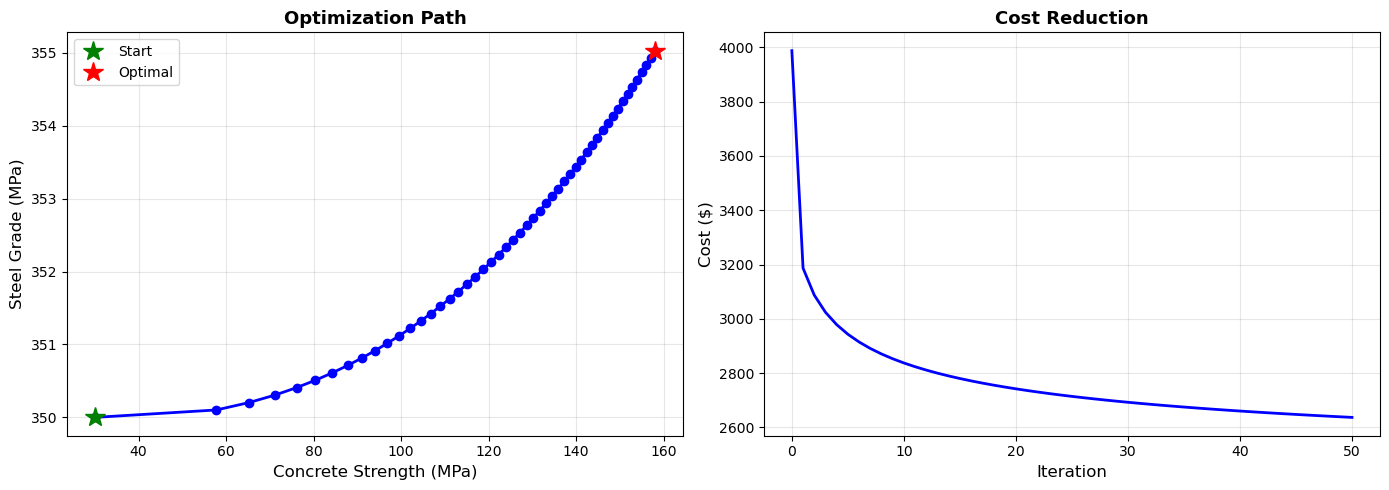

In [24]:
# Cost optimization
cost_result = cost_function_gradient()

print("Cost Function Optimization")
print("=" * 50)
print(f"\nInitial parameters: fc = {cost_result['optimization']['initial_params'][0]:.2f} MPa, fy = {cost_result['optimization']['initial_params'][1]:.2f} MPa")
print(f"Initial cost: ${cost_result['optimization']['initial_cost']:.2f}")
print(f"\nOptimal parameters: fc = {cost_result['optimization']['optimal_params'][0]:.2f} MPa, fy = {cost_result['optimization']['optimal_params'][1]:.2f} MPa")
print(f"Optimal cost: ${cost_result['optimization']['optimal_cost']:.2f}")
print(f"\nSavings: ${cost_result['optimization']['savings']:.2f}")

# Plot optimization path
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Parameter trajectory
history = cost_result['optimization']['history']
ax1.plot(history[:, 0], history[:, 1], 'bo-', linewidth=2, markersize=6)
ax1.plot(history[0, 0], history[0, 1], 'g*', markersize=15, label='Start')
ax1.plot(history[-1, 0], history[-1, 1], 'r*', markersize=15, label='Optimal')
ax1.set_xlabel('Concrete Strength (MPa)', fontsize=12)
ax1.set_ylabel('Steel Grade (MPa)', fontsize=12)
ax1.set_title('Optimization Path', fontsize=13, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Cost history
cost_history = cost_result['optimization']['cost_history']
ax2.plot(cost_history, 'b-', linewidth=2)
ax2.set_xlabel('Iteration', fontsize=12)
ax2.set_ylabel('Cost ($)', fontsize=12)
ax2.set_title('Cost Reduction', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 📚 Section 11: Summary & Key Takeaways

## 🎯 Key Concepts Covered

### 1. **Derivatives and Gradients**
- Derivative: rate of change for single variable
- Partial derivative: rate of change holding others constant
- Gradient: vector of all partial derivatives
- Direction of steepest increase

### 2. **Jacobians**
- Matrix of partial derivatives for vector functions
- Size: $m \times n$ for $\mathbb{R}^n \to \mathbb{R}^m$
- $J_{ij} = \frac{\partial f_i}{\partial x_j}$

### 3. **Chain Rule**
- Scalar: $\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$
- Vector: $\nabla_{\mathbf{x}} y = (\mathbf{J}_{\mathbf{g}})^T \nabla_{\mathbf{z}} y$
- Jacobian: $\mathbf{J}_{\mathbf{y}} = \mathbf{J}_{\mathbf{f}} \cdot \mathbf{J}_{\mathbf{g}}$

### 4. **Automatic Differentiation**
- Forward-mode: dual numbers, one pass per input
- Backward-mode: adjoints, one pass for all inputs
- Neither symbolic nor numerical
- Exact derivatives with machine precision

### 5. **Computation Graphs**
- Directed Acyclic Graph (DAG)
- Nodes: variables/operations
- Edges: data flow
- Enables efficient autodiff

### 6. **Backpropagation**
- Reverse-mode autodiff on computation graphs
- Forward pass: compute values
- Backward pass: compute gradients
- Foundation of neural network training

## 🔗 Connections to Machine Learning

| Vector Calculus Concept | ML Application |
|-------------------------|----------------|
| Gradient | Gradient descent optimization |
| Jacobian | Neural network layer derivatives |
| Chain rule | Backpropagation through layers |
| Autodiff | PyTorch, TensorFlow internals |
| Computation graph | Model architecture |
| Backpropagation | Training deep networks |

## 💡 Key Insights for CE

1. **Gradients reveal sensitivity:** How outputs change with inputs
2. **Optimization requires gradients:** Gradient descent, Newton's method
3. **Sensitivity analysis:** Identify critical design parameters
4. **Uncertainty propagation:** How input uncertainty affects outputs
5. **Inverse problems:** Use gradients to find inputs from desired outputs
6. **Automated tools:** Modern frameworks handle derivatives automatically
7. **Computational efficiency:** Backprop is much faster than finite differences

## 📖 Further Reading

1. **Books:**
   - *Deep Learning* by Goodfellow, Bengio & Courville (Chapter 6)
   - *Automatic Differentiation in Machine Learning* by Baydin et al.
   - *Numerical Optimization* by Nocedal & Wright

2. **Online Resources:**
   - CS231n: Convolutional Neural Networks (Stanford)
   - Automatic Differentiation tutorial (autodiff.org)
   - PyTorch Autograd documentation

3. **Practice:**
   - Implement backprop from scratch
   - Derive gradients for custom loss functions
   - Build computation graphs manually
   - Compare autodiff with numerical gradients

## 🎓 Review Questions

1. What is the difference between a gradient and a Jacobian?
2. How does the chain rule enable backpropagation?
3. What are the advantages of autodiff over numerical differentiation?
4. Explain forward-mode vs backward-mode autodiff.
5. Why is backpropagation efficient for neural networks?
6. How do computation graphs represent functions?
7. What is an adjoint (upstream gradient)?
8. How does sensitivity analysis help in CE design?
9. Why do gradients point in the direction of steepest increase?
10. What is the cost of backpropagation compared to forward pass?

# 🎉 Congratulations!

You've completed the Vector Calculus and Backpropagation notebook!

**You should now understand:**
- ✓ Derivatives, gradients, and Jacobians
- ✓ Chain rule for scalar and vector functions
- ✓ Physical meaning of gradients
- ✓ Automatic differentiation (forward and backward modes)
- ✓ Computation graphs
- ✓ Backpropagation algorithm
- ✓ Neural network training
- ✓ CE applications (sensitivity analysis)

**Next Lecture:** Regression Models

*Notebook created for CE639: AI for Civil Engineering*  
*IIT Gandhinagar*